## Email Processing System

In [1]:
from IPython.display import display, Image
from typing import TypedDict, List, Dict, Any, Optional
from langgraph.graph import StateGraph, START, END
from langchain_ollama import ChatOllama
from langchain_core.messages import HumanMessage

### Define Our State

In [2]:
class EmailState(TypedDict):
    # The email being processed
    email: Dict[str, Any]

    # Category of the email
    email_category: Optional[str]

    # Analysis and decisions
    is_spam: Optional[bool]

    # Reason why the email was marked as spam
    spam_reason: Optional[str]
    
    # Response generation
    email_draft: Optional[str]
    
    # Processing metadata
    messages: List[Dict[str, Any]]

### Define Our Nodes

In [3]:
# Initialize our LLM
model = ChatOllama(
    model="llama3.2",
    temperature=0
)

In [ ]:
# Node: logs the incoming email before it gets classified
def read_email(state: EmailState):
    """Agent reads and logs the incoming email"""
    email = state["email"]
    print(f"Agent is processing an email from {email['sender']} with subject: {email['subject']}")
    return {}

In [ ]:
# Node: classifies the email as SPAM or LEGITIMATE using the LLM
def classify_email(state: EmailState):
    """Agent uses an LLM to determine if the email is spam or legitimate"""
    email = state["email"]

    # Build the prompt
    prompt = f"""
    You are an email classification agent.

    Your job is to classify the email as either SPAM or LEGITIMATE.

    SPAM means:
    - unsolicited advertising or promotions
    - scams or fraudulent requests
    - phishing attempts
    - malicious or suspicious requests
    - unwanted bulk messages

    LEGITIMATE means:
    - normal business communication
    - genuine questions or inquiries
    - requests for information
    - customer complaints
    - requests to schedule meetings or calls
    - thank-you messages
    - other normal personal or professional communication

    Important:
    Do NOT classify an email as spam simply because:
    - the sender is unknown
    - the sender uses a generic email address
    - the email asks about services
    - the email asks to schedule a call

    Email:
    From: {email['sender']}
    Subject: {email['subject']}
    Body: {email['body']}

    First decide whether the email is SPAM or LEGITIMATE.
    Then explain your decision.
    If it is legitimate, give its category (inquiry, complaint, thank you, request, or information).
    If it is spam, add a line formatted exactly as: Reason: <short reason>

    Your answer must start with either:
    SPAM
    or
    LEGITIMATE
    """

    # Call the LLM
    messages = [HumanMessage(content=prompt)]
    response = model.invoke(messages)
    response_text = response.content.strip()
    response_lower = response_text.lower()

    # Classify from the model's actual verdict
    first_line = response_lower.splitlines()[0] if response_lower else ""
    is_spam = first_line.startswith("spam")

    # Extract a reason if it's spam
    spam_reason = None
    if is_spam and "reason:" in response_lower:
        spam_reason = response_text[response_lower.index("reason:") + len("reason:"):].strip()

    # Determine category if legitimate
    email_category = None
    if not is_spam:
        categories = ["inquiry", "complaint", "thank you", "request", "information"]
        for category in categories:
            if category in response_lower:
                email_category = category
                break

    # Update messages for tracking
    new_messages = state.get("messages", []) + [
        {"role": "user", "content": prompt},
        {"role": "assistant", "content": response.content}
    ]

    # Return state updates
    return {
        "is_spam": is_spam,
        "spam_reason": spam_reason,
        "email_category": email_category,
        "messages": new_messages
    }

In [6]:
# Node: runs when the email was classified as spam
def handle_spam(state: EmailState):
    """Agent discards spam email with a note"""
    print(f"Agent has marked the email as spam. Reason: {state['spam_reason']}")
    print("The email has been moved to the spam folder.")
    return {}

In [7]:
# Node: runs when the email is legitimate, drafts a reply with the LLM
def draft_response(state: EmailState):
    """Agent drafts a preliminary response for legitimate emails"""
    email = state["email"]
    category = state["email_category"] or "general"
    
    # Prepare our prompt for the LLM
    prompt = f"""
    As Agent the butler, draft a polite preliminary response to this email.
    
    Email:
    From: {email['sender']}
    Subject: {email['subject']}
    Body: {email['body']}
    
    This email has been categorized as: {category}
    
    Draft a brief, professional response that the receiver can review and personalize before sending.
    """
    
    # Call the LLM
    messages = [HumanMessage(content=prompt)]
    response = model.invoke(messages)
    
    # Update messages for tracking
    new_messages = state.get("messages", []) + [
        {"role": "user", "content": prompt},
        {"role": "assistant", "content": response.content}
    ]
    
    # Return state updates
    return {
        "email_draft": response.content,
        "messages": new_messages
    }

In [8]:
# Node: shows the user the email + the drafted reply for review
def notify_receiver(state: EmailState):
    """Agent notifies the receiver about the email and presents the draft response"""
    email = state["email"]
    
    print("\n" + "="*50)
    print(f"Sir, you've received an email from {email['sender']}.")
    print(f"Subject: {email['subject']}")
    print(f"Category: {state['email_category']}")
    print("\nI've prepared a draft response for your review:")
    print("-"*50)
    print(state["email_draft"])
    print("="*50 + "\n")
    return {}

### Define Our Routing Logic

In [9]:
# Conditional edge: picks the next node based on the spam classification
def route_email(state: EmailState) -> str:
    """Determine the next step based on spam classification"""
    if state["is_spam"]:
        return "spam"
    else:
        return "legitimate"

### Create the StateGraph and Define Edges

In [10]:
# Create the graph
email_graph = StateGraph(EmailState)

In [11]:
# Add nodes
email_graph.add_node("read_email", read_email)
email_graph.add_node("classify_email", classify_email)
email_graph.add_node("handle_spam", handle_spam)
email_graph.add_node("draft_response", draft_response)
email_graph.add_node("notify_receiver", notify_receiver)

In [12]:
# Start the edges
email_graph.add_edge(START, "read_email")

# Add edges
email_graph.add_edge("read_email", "classify_email")

In [13]:
# Add conditional branching from classify_email
email_graph.add_conditional_edges(
    "classify_email",
    route_email,
    {
        "spam": "handle_spam",
        "legitimate": "draft_response"
    }
)

In [14]:
# Add the final edges
email_graph.add_edge("handle_spam", END)
email_graph.add_edge("draft_response", "notify_receiver")
email_graph.add_edge("notify_receiver", END)

In [15]:
# Compile the graph
compiled_graph = email_graph.compile()

### Run the Application

In [16]:
# Example legitimate email
legitimate_email = {
    "sender": "john.smith@example.com",
    "subject": "Question about your services",
    "body": "Dear Agent, I was referred to you by a colleague and I'm interested in learning more about your consulting services. Could we schedule a call next week? Best regards, John Smith"
}

# Example spam email
spam_email = {
    "sender": "winner@lottery-intl.com",
    "subject": "YOU HAVE WON $5,000,000!!!",
    "body": "CONGRATULATIONS! You have been selected as the winner of our international lottery! To claim your $5,000,000 prize, please send us your bank details and a processing fee of $100."
}

In [17]:
# Process the legitimate email
print("\nProcessing legitimate email...")
legitimate_result = compiled_graph.invoke({
    "email": legitimate_email,
    "is_spam": None,
    "spam_reason": None,
    "email_category": None,
    "email_draft": None,
    "messages": []
})


Processing legitimate email...
Agent is processing an email from john.smith@example.com with subject: Question about your services

Sir, you've received an email from john.smith@example.com.
Subject: Question about your services
Category: request

I've prepared a draft response for your review:
--------------------------------------------------
Here's a polite preliminary response:

Dear Mr./Ms. Smith,

Thank you for considering my consulting services and for being referred by your colleague. I'd be delighted to discuss how I can assist you.

Before scheduling a call, could you please let me know what specific areas of consulting you're interested in learning more about? This will enable me to tailor our conversation and ensure we make the most of our time together.

I'm available [insert days/times] next week. Would any of these options work for you, or would you prefer a different schedule?

Looking forward to speaking with you soon.

Best regards,
Agent



In [18]:
# Process the spam email
print("\nProcessing spam email...")
spam_result = compiled_graph.invoke({
    "email": spam_email,
    "is_spam": None,
    "spam_reason": None,
    "email_category": None,
    "email_draft": None,
    "messages": []
})


Processing spam email...
Agent is processing an email from winner@lottery-intl.com with subject: YOU HAVE WON $5,000,000!!!
Agent has marked the email as spam. Reason: Unsolicited advertising or promotions. The email claims the recipient has won a large sum of money and asks for personal financial information, which is a common tactic used in scams and phishing attempts.
The email has been moved to the spam folder.


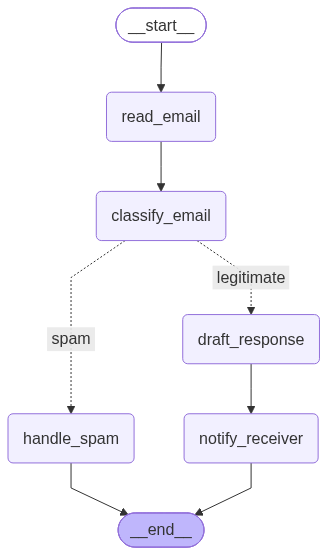

In [19]:
display(Image(compiled_graph.get_graph().draw_mermaid_png()))